# 02 · Rejilla, armonización y cobertura territorial

Implementa los pasos **13–17 de la fase C** del plan. Continúa los cuadernos 00 y 01
desde archivos persistidos, sin depender de sus kernels. El procesamiento reutilizable
está en `src/geoau/territory.py`; las decisiones reproducibles, en `config/grid.yaml`.

**Entregables:** rejilla territorial de 1 km con área terrestre, diccionario de soportes,
ocho familias vectoriales base y ocho capas recuperadas saneadas, diez rásteres agregados, `coverage.gpkg`, mapa,
diagnósticos por bloques de 50 km y correspondencia indicio–celda.

Ejecuta todo con `.venv-fase-a/Scripts/python.exe`. El saneamiento completo de las
capas millonarias tarda y escribe varios GB por ejecución. Cada ejecución tiene una
carpeta nueva; los originales y las fases anteriores se conservan.

Máscara candidata: GISCO Countries 2024, escala 1:1.000.000.
© EuroGeographics para los límites administrativos. Fuente consultada el 7/9/2026.
Sus condiciones específicas permiten uso no comercial y exigen atribución; no se
presupone autorización comercial. Véanse las referencias al final.

## 1. Lectura crítica del plan y contrato entre fases

La fase A acredita fuentes locales y hashes. La fase B seleccionada terminó su ejecución,
pero mantiene pendientes la revisión de presencia, depósitos, distritos y territorio.
Los candidatos Au no se convierten aquí en positivos revisados. Las numerosas filas
de maestros enriquecidos tampoco se añaden como muestras nuevas.

| Decisión | Aplicación en C | Límite que conserva |
|---|---|---|
| Ámbito | Componente continental principal de España | Islas y enclaves se inventarían fuera de V1 |
| Frontera | Máscara independiente de los TIFF | Generalización cartográfica; revisión costera pendiente |
| Rejilla | 1 km ETRS89/UTM 30N, origen fijo | Área proyectada; se cuantifica distorsión |
| Etiquetas | Relación registro–celda, sin multiplicar celdas | No se deducen depósitos ni ausencias |
| Geoquímica | Banda de clases, moda y proporciones alternativas | No son análisis continuos; validación RGB/leyenda en D |
| Estructuras | Geometría lineal 2D, códigos y fuente conservados | Limpieza semántica y deduplicación entre fuentes en D |
| Cobertura | Disponibilidad por superficie y bloques | Sin huellas de levantamiento no se acredita cobertura de líneas |

**La finalización informática no cierra automáticamente el hito H2 científico.**
Las limitaciones restantes quedan en `control_cierre.json`; no se emite favorabilidad.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config/project.yaml").is_file())
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
import yaml
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display
from geoau.territory import (start_run, grid_spec, load_mask, land_areas, make_grid,
    feature_dictionary, align_rasters, harmonize_vectors, coverage_products, finish_run)
CONFIG = yaml.safe_load((ROOT / "config/grid.yaml").read_text(encoding="utf-8"))
SPEC = grid_spec(CONFIG)
pd.set_option("display.max_colwidth", 95)
print("Intérprete:", sys.executable)
display(pd.Series(CONFIG).to_frame("configuración"))

Intérprete: C:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\.venv-fase-a\Scripts\python.exe


,configuración
schema_version,1
phase_b_run,reports/fase_b/20260908T085820_294458Z
vector_cache_run,reports/fase_c/20260907T194217_760616Z
output_directory,reports/fase_c
mask_path,data/raw/territorio/ES-region-01m-4326-2024.geojson
mask_metadata,data/raw/territorio/provenance.json
mask_status,candidata_regional_generalizada_1M
scope,peninsula_componente_principal
grid_version,es_pen_utm30_1km_v1
crs,EPSG:25830


## 2. Recuperar las entradas exactas de A y B

Se fija explícitamente la ejecución de B en configuración. Se sigue su enlace a A y
se comprueba el hash de ese manifiesto, las 93 fuentes y las entradas adicionales de B.
No se elige una fase A diferente por ser más reciente. Las salidas de B no tenían un
manifiesto de hashes propio: C registra sus hashes al abrirlas, sin fingir una firma
histórica inexistente. La máscara nueva tiene procedencia y SHA-256 independientes.

In [2]:
RUN_DIR, FUENTES, MANIFEST_A, ENTRADAS_C, indicios = start_run(ROOT, CONFIG)
print("Resultados:", RUN_DIR)
display(indicios.Codigo_indicio_raw)
print("Candidatos de B:", len(indicios))
print("Positivos revisados de B:", int(indicios.elegible_general_revisada.sum()))
display(indicios[["record_id", "Codigo_indicio", "Provincia", "tipo_au_propuesto",
                  "elegible_general_revisada"]].head())

Resultados: C:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\reports\fase_c\20260908T103618_420135Z


0      0006001
1      0006002
2      0007002
3      0007006
4      0007009
        ...   
785    1046032
786    1046047
787    1064030
788    1065024
789    1066035
Name: Codigo_indicio_raw, Length: 790, dtype: str

Candidatos de B: 790
Positivos revisados de B: 0


,record_id,Codigo_indicio,Provincia,tipo_au_propuesto,elegible_general_revisada
0,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:20,0006001,CORUÑA,roca,False
1,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:21,0006002,CORUÑA,roca,False
2,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:23,0007002,CORUÑA,roca,False
3,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:27,0007006,CORUÑA,desconocido,False
4,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:30,0007009,CORUÑA,desconocido,False


## 3. Máscara y ámbitos — paso 13

Se selecciona la componente mayor por área en EPSG:3035, no por grados cuadrados ni
por extensión de la geoquímica. Esa componente define la península continental;
las islas costeras separadas también quedan fuera de esta primera versión. Todas
las componentes españolas se guardan en `coverage.gpkg/ambitos_espana` con su estado.

Es una máscara regional **candidata**, no una delimitación topográfica fina. No permite
certificar por sí sola costa exacta, aguas interiores ni localización administrativa.
No se mueven indicios para hacerlos coincidir con ella.

In [3]:
mascara = load_mask(ROOT, CONFIG, RUN_DIR)
display(pd.read_csv(RUN_DIR / "ambitos_espana.csv").groupby("ambito").agg(
    componentes=("ambito", "size"), area_km2=("area_km2_epsg3035", "sum")))
print("Área candidata en UTM30, km²:", mascara.area / 1e6)

,componentes,area_km2
ambito,,
fuera_ambito_v1,96,12548.485024
peninsula,1,493453.365552


Área candidata en UTM30, km²: 493639.6116913978


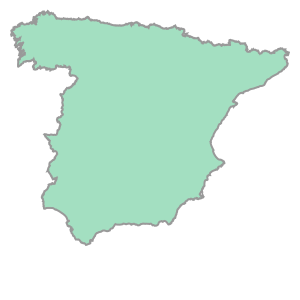

In [4]:
mascara

## 4. Rejilla estable y política costera — paso 13

La caja fija tiene **1.100 × 910 celdas de 1 km**, pero solo se guardan filas con
intersección terrestre positiva. `cell_id` combina versión, fila y columna; no depende
del número de indicios, de la cobertura ni del orden de lectura.

El área se calcula intersectando la máscara con el soporte fuente de 500 m y sumando
bloques 2×2. Los píxeles interiores tienen su área completa; en el borde se usa overlay
geométrico exacto. Se comprueba que la suma conserva el área de la máscara.

Se conservan también las celdas con poca tierra. Para el diagnóstico de elegibilidad
se exige inicialmente al menos **50 % terrestre**, umbral configurable fijado antes
de modelizar. Los centros siguen siendo los centros de los cuadrados, incluso si
caen en mar: no se cambian solo para las presencias. La inferencia futura usará ese
mismo soporte. El área efectiva siempre será terrestre, no el número de cuadrados.

In [5]:
area_terrestre_500m = land_areas(mascara, SPEC["native_shape"], SPEC["native_transform"])
grid = make_grid(area_terrestre_500m, SPEC, RUN_DIR)
display(grid[grid["land_fraction"] == 0].head())
display(grid[["land_area_m2", "land_fraction"]].describe())
print("Celdas terrestres:", len(grid), "de", SPEC["width"] * SPEC["height"])
display(pd.read_csv(RUN_DIR / "distorsion_crs.csv")[["linear_scale_error_pct", "area_scale_error_pct"]].agg(["min", "max"]))

,row,col,cell_id,x_center,y_center,land_area_m2,land_fraction,coastal_eligible,diagnostic_block


,land_area_m2,land_fraction
count,496855.000000,4.968550e+05
mean,993528.517760,9.935285e-01
std,69074.161074,6.907416e-02
min,0.618553,6.185531e-07
25%,1000000.000000,1.000000e+00
50%,1000000.000000,1.000000e+00
75%,1000000.000000,1.000000e+00
max,1000000.000000,1.000000e+00


Celdas terrestres: 496855 de 1001000


,linear_scale_error_pct,area_scale_error_pct
min,-0.040000,-0.079983
max,0.293505,0.587871


`grid_spec.json` contiene transformada GDAL, CRS, origen, extensión y forma. Se guarda
`grid_1km.csv.gz`, reconstruible desde fila/columna, en lugar de cientos de miles de
polígonos repetidos. `coverage.gpkg` contiene geometrías agrupadas de los estados.
Cambiar origen, resolución o ámbito exige una nueva versión de rejilla. El contraste
a 500 m del plan será un experimento posterior, no un segundo modelo creado aquí.

In [6]:
display(grid[grid["land_fraction"] > 0])

,row,col,cell_id,x_center,y_center,land_area_m2,land_fraction,coastal_eligible,diagnostic_block
0,0,172,es_pen_utm30_1km_v1_r0000_c0172,122500.0,4859500.0,5644.982426,0.005645,False,b0_3
1,0,173,es_pen_utm30_1km_v1_r0000_c0173,123500.0,4859500.0,17137.402569,0.017137,False,b0_3
2,1,172,es_pen_utm30_1km_v1_r0001_c0172,122500.0,4858500.0,135137.412310,0.135137,False,b0_3
3,1,173,es_pen_utm30_1km_v1_r0001_c0173,123500.0,4858500.0,836118.042784,0.836118,True,b0_3
4,1,174,es_pen_utm30_1km_v1_r0001_c0174,124500.0,4858500.0,91499.172308,0.091499,False,b0_3
...,...,...,...,...,...,...,...,...,...
496850,871,314,es_pen_utm30_1km_v1_r0871_c0314,264500.0,3988500.0,326826.140433,0.326826,False,b17_6
496851,871,315,es_pen_utm30_1km_v1_r0871_c0315,265500.0,3988500.0,872445.010177,0.872445,True,b17_6
496852,871,316,es_pen_utm30_1km_v1_r0871_c0316,266500.0,3988500.0,625765.297077,0.625765,True,b17_6
496853,871,317,es_pen_utm30_1km_v1_r0871_c0317,267500.0,3988500.0,379044.156958,0.379044,False,b17_6


## 5. Diccionario de extracción — paso 14

El diccionario fija el contrato P/U/inferencia. En las celdas costeras, medias y
proporciones usan el área terrestre válida de cada píxel fuente. La fracción válida
divide área con dato entre área terrestre total, no entre toda la celda incluyendo mar.

Litología/edad se definirán mediante intersecciones y fracciones; las distancias, desde
el centro fijo; las densidades, mediante longitud por superficie en ventanas. En fase C
no se confunde un diagnóstico de cobertura con una variable geológica terminada.
La fórmula y ventana de cada derivado de relieve se deben fijar en D antes de calcularlo.

In [7]:
diccionario = feature_dictionary(RUN_DIR)
display(diccionario)

,feature,source,support,units,status,same_for_P_U_inference,missing_policy,predictor_policy
0,litologia_fracciones_dominante,litologia/recintos,interseccion_poligonal/area_terrestre,fraccion/categoria,fase_D,True,NoData; no rellenar con 0; imputacion solo dentro de entrenamiento,"una representacion por elemento; no incluir IDs, coordenadas ni etiquetas"
1,edad_fracciones_dominante,edades/recintos,interseccion_poligonal/area_terrestre,fraccion/categoria,fase_D,True,NoData; no rellenar con 0; imputacion solo dentro de entrenamiento,"una representacion por elemento; no incluir IDs, coordenadas ni etiquetas"
2,distancia_estructuras,contactos_geode/estructuras_magna,centro_geometrico_fijo_de_celda_a_linea_clasificada,m,fase_D,True,NoData; no rellenar con 0; imputacion solo dentro de entrenamiento,"una representacion por elemento; no incluir IDs, coordenadas ni etiquetas"
3,densidad_estructuras,contactos_geode/estructuras_magna,longitud_en_circulo_1_5_10km/area_soporte_valido,km/km2,fase_D,True,NoData; no rellenar con 0; imputacion solo dentro de entrenamiento,"una representacion por elemento; no incluir IDs, coordenadas ni etiquetas"
4,distancia_cauce,hidrografia,centro_geometrico_fijo_de_celda_a_red,m,fase_D,True,NoData; no rellenar con 0; imputacion solo dentro de entrenamiento,"una representacion por elemento; no incluir IDs, coordenadas ni etiquetas"
5,elevacion_media,relieve_banda_1,media_ponderada_por_area_terrestre_valida,m,armonizada_C,True,NoData; no rellenar con 0; imputacion solo dentro de entrenamiento,"una representacion por elemento; no incluir IDs, coordenadas ni etiquetas"
6,pendiente_TPI_rugosidad,relieve_banda_1,ventana_y_formula_a_fijar_en_D_con_NoData_y_margen,segun_variable,fase_D,True,NoData; no rellenar con 0; imputacion solo dentro de entrenamiento,"una representacion por elemento; no incluir IDs, coordenadas ni etiquetas"
7,au_clase,geoquimica_au_banda_1,moda_area_valida; empate_clase_menor; proporciones_alternativas,clase_ordinal,armonizada_C_leyenda_pendiente_D,True,NoData; no rellenar con 0; imputacion solo dentro de entrenamiento,"una representacion por elemento; no incluir IDs, coordenadas ni etiquetas"
8,as_clase,geoquimica_as_banda_1,moda_area_valida; empate_clase_menor; proporciones_alternativas,clase_ordinal,armonizada_C_leyenda_pendiente_D,True,NoData; no rellenar con 0; imputacion solo dentro de entrenamiento,"una representacion por elemento; no incluir IDs, coordenadas ni etiquetas"
9,sb_clase,geoquimica_sb_banda_1,moda_area_valida; empate_clase_menor; proporciones_alternativas,clase_ordinal,armonizada_C_leyenda_pendiente_D,True,NoData; no rellenar con 0; imputacion solo dentro de entrenamiento,"una representacion por elemento; no incluir IDs, coordenadas ni etiquetas"


## 6. Agregación de rásteres y máscaras — paso 16

Los nueve TIFF geoquímicos y el MDT deben coincidir exactamente con la rejilla fuente
de 500 m. Si cambia CRS, forma u origen, el proceso se detiene: no disimula un desfase
con remuestreo automático. Lee por ventanas y agrega bloques 2×2 sin desplazar píxeles.

- **Geoquímica:** banda 1, códigos enteros 0–6 u 0–7. Moda ponderada por superficie
  terrestre válida; en empate gana el código menor. Se exportan las proporciones como
  alternativa de representación. No incluir moda y todas las proporciones como
  evidencias independientes sin un experimento justificado.
- **Relieve:** solo elevación, media ponderada; pendiente/TPI/TRI antiguos no se heredan.
- **Ausencia de dato:** `-9999` en el producto; fracción válida 0 dentro de tierra sin
  datos. Fuera de tierra, fracción NoData. **Clase 0 es una clase válida**.

Se conservan las carencias; no se interpolan códigos, ni se convierten intervalos en
mediciones. Revisar clasificación desde RGB y unidades pertenece al paso 21 de D.

In [37]:
fracciones_raster = align_rasters(ROOT, FUENTES, area_terrestre_500m, SPEC, RUN_DIR)
display(pd.read_csv(RUN_DIR / "raster_alignment.csv"))

Alineando relieve


KeyboardInterrupt: 

## 7. Saneamiento vectorial por lotes — paso 15

Se usa el índice espacial del GeoPackage y se pagina por FID ordenado, comprobando
el recuento contra una consulta independiente. Se leen entidades del ámbito más un
margen de **20 km**, suficiente para las ventanas iniciales de hasta 10 km. Se
conservan las geometrías completas que intersectan el margen para evitar cortar trazas.

Las coordenadas se transforman a EPSG:25830; Z/M no se utilizan. La linealización GDAL
tiene paso angular de 1° y se contrasta con 0,5° en 1.000 entidades de GEODE mediante
Hausdorff en metros. Este contraste es muestral: no certifica todas las curvas ni una
tolerancia métrica global. Las advertencias del lector quedan registradas.

`make_valid` repara geometrías inválidas, conservando códigos y `source_fid`. Se registran
áreas/longitudes antes y después, cambios de tipo y rechazos. Geometrías vacías o de
dimensión inesperada quedan en el registro de incidencias para revisión por FID.
No se sustituyen por geometrías inventadas ni se mezclan GEODE y MAGNA.

La fracción cubierta por polígonos es una **estimación por centros de 500 m** ponderada
por tierra. Los solapes cuentan multiplicidad de entidades; no demuestran duplicación
de contenido. En líneas se guarda presencia de trazas, que **no acredita cobertura
del levantamiento**. Clasificar fallas/contactos, revisar discontinuidades por hoja y
resolver duplicados entre fuentes sigue pendiente.

In [9]:
fracciones_vector, control_vectores = harmonize_vectors(ROOT, FUENTES, mascara,
    area_terrestre_500m, SPEC, RUN_DIR)
display(control_vectores.drop(columns=["reader_warnings", "z_m_policy", "semantic_status"]))

Verificando y copiando paso vectorial completo: C:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\reports\fase_c\20260907T194217_760616Z


,familia,source_features,read_bbox,expected_bbox,pagination_complete,kept_with_margin,invalid_before,quarantine_count,changed_geometry_types,crs_source,crs_target,area_support_km2_estimated,area_overlap_km2_estimated,coverage_status,curve_sample_hausdorff_m
0,litologia,16007,15674,15674,True,15373,39,0,39,EPSG:3857,EPSG:25830,492115.990358,0.0,estimada_centros_500m,NaN
1,edades,16007,15674,15674,True,15373,39,0,39,EPSG:3857,EPSG:25830,492115.990358,0.0,estimada_centros_500m,NaN
2,recintos,612170,581343,581343,True,572449,1632,6,1608,EPSG:3857,EPSG:25830,459968.177423,146.0,estimada_centros_500m,NaN
3,contactos_geode,2126026,2049532,2049532,True,2011285,0,0,0,EPSG:3857,EPSG:25830,NaN,NaN,desconocida_sin_huella_de_levantamiento,0.0
4,estructuras_magna,2229505,2190126,2190126,True,2142641,0,0,0,EPSG:3857,EPSG:25830,NaN,NaN,desconocida_sin_huella_de_levantamiento,NaN
5,ejes_geode,27556,27554,27554,True,27149,0,0,0,EPSG:3857,EPSG:25830,NaN,NaN,desconocida_sin_huella_de_levantamiento,NaN
6,pliegues_magna,31801,31799,31799,True,31353,0,0,0,EPSG:3857,EPSG:25830,NaN,NaN,desconocida_sin_huella_de_levantamiento,NaN
7,hidrografia,13396,13346,13346,True,13148,0,0,0,EPSG:4258,EPSG:25830,NaN,NaN,desconocida_sin_huella_de_levantamiento,NaN


## 7b. Capas recuperadas — pasos 14–17

La fase A del 8/9/2026 ya inventaría estas ocho capas con datos. Se usan las copias
del proyecto, comprobadas por SHA-256; no se mezclan con los GPKG vacíos anteriores.
La caché base solo se reutiliza si sus ocho fuentes, algoritmo, máscara y parámetros
geométricos coinciden. Un cambio de etiquetas o la adición de otras familias no
invalida por sí solo esas geometrías. Cada producto reutilizado se verifica por hash.

| Capa | Contenido observado | Tratamiento en C |
|---|---|---|
| Magnetometría/radiometría | 3.811 líneas de vuelo | Conservar trazas y campaña; `VALU_LINE` no se interpreta como anomalía |
| Magnetotelúrica | 73 sitios, perfiles y archivos EDI | Presencia de sitios; sin inferir resistividad ni profundidad |
| Petrofísica | 2.780 localizaciones con referencias | Sin inferir propiedades físicas ausentes en los atributos |
| Gravimetría | 241.355 puntos y `VALU_BOU267` | Conservar valores y diagnóstico; unidades, correcciones y centinelas pendientes |
| Buzamientos | 225.450 puntos Z y simbología | Pasar a 2D conservando Z original; no equiparar ROTATION a dirección sin leyenda |
| Medidas estructurales | 251.654 líneas con DIRECCION/BUZAMIENTO | Conservar geometría y ángulos; revisar rangos; no usar longitud del símbolo como falla |
| Cuaternario | 44.464 polígonos | Huella temática; auxiliares no equivalen automáticamente a terrazas |
| Zonas GEODE | 28 polígonos con códigos/nombres | Ámbitos cartográficos; no son distritos metalogenéticos validados |

Se leen todas las filas en lotes y se distinguen geometrías inválidas de geometrías
fuera del ámbito más margen. Las extensiones insulares se registran fuera del ámbito
peninsular, sin reasignar CRS por conjetura. Los campos angulares y físicos se conservan;
los controles de rango son diagnósticos, no correcciones automáticas.

**La ocupación de una celda por un punto o una traza no es cobertura del levantamiento.**
La huella de cuaternario tampoco permite etiquetar su exterior como ausencia de ese
material. Se generan diagnósticos separados y no se convierten estas ocho capas en
requisitos del conjunto básico ni se interpolan superficies geofísicas.


In [10]:
from geoau.additional_layers import harmonize_additional
control_adicionales = harmonize_additional(ROOT, FUENTES, mascara, area_terrestre_500m, SPEC, RUN_DIR)
display(control_adicionales[["familia", "source_features", "kept_with_margin", "invalid_before",
                              "quarantine_count", "outside_scope_margin", "support_role"]])
display(pd.read_csv(RUN_DIR / "additional_attribute_qc.csv"))


magnetometriaradiometria 3811 / 3811


magnetotelurico 73 / 73


medidasestructurales 50000 / 251654


medidasestructurales 100000 / 251654


medidasestructurales 150000 / 251654


...

gravimetria 200000 / 241355


gravimetria 241355 / 241355


zonasgeode 28 / 28


,familia,source_features,kept_with_margin,invalid_before,quarantine_count,outside_scope_margin,support_role
0,magnetometriaradiometria,3811,3811,0,0,0,"lineas_de_vuelo; VALU_LINE es identificador, no anomalia magnetica"
1,magnetotelurico,73,73,0,0,0,sitios_y_referencias_EDI; sin modelo resistivo ni profundidad en atributos
2,medidasestructurales,251654,247795,0,0,3859,simbolos_lineales_con_angulos; longitud no equivale a estructura geologica
3,petrofisica,2780,2780,0,0,0,localizaciones_documentales; sin propiedades fisicas cuantitativas en atributos
4,buzamientos,225450,220688,0,0,4762,simbolos_puntuales; ROTATION y STRING requieren convenciones de leyenda
5,cuaternariorecintos,44464,43211,0,2,1251,huella_materiales_cuaternarios; no acredita cobertura del levantamiento ni ausencia fuera
6,gravimetria,241355,237830,0,0,3525,"observaciones_con_VALU_BOU267; unidades, correcciones y centinelas pendientes"
7,zonasgeode,28,18,1,0,10,zonas_cartograficas_GEODE; no distritos ni dominios metalogeneticos validados


,familia,campo,filas,nulos_o_no_numericos,no_finitos,fuera_rango_angular_candidato,minimo_observado,maximo_observado,interpretacion
0,medidasestructurales,DIRECCION,50000,0,0,0,0.000,360.000000,no filtrar ni imputar automaticamente; requiere metadatos
1,medidasestructurales,BUZAMIENTO,50000,0,0,10,0.000,700.000000,no filtrar ni imputar automaticamente; requiere metadatos
2,medidasestructurales,DIRECCION,50000,0,0,0,0.000,360.000000,no filtrar ni imputar automaticamente; requiere metadatos
3,medidasestructurales,BUZAMIENTO,50000,0,0,24,0.000,776.000000,no filtrar ni imputar automaticamente; requiere metadatos
4,medidasestructurales,DIRECCION,50000,249,0,0,0.000,360.000000,no filtrar ni imputar automaticamente; requiere metadatos
5,medidasestructurales,BUZAMIENTO,50000,93,0,10,0.000,370.000000,no filtrar ni imputar automaticamente; requiere metadatos
6,medidasestructurales,DIRECCION,50000,2,0,0,0.000,360.000000,no filtrar ni imputar automaticamente; requiere metadatos
7,medidasestructurales,BUZAMIENTO,50000,2,0,16,0.000,7000.000000,no filtrar ni imputar automaticamente; requiere metadatos
8,medidasestructurales,DIRECCION,50000,0,0,0,0.000,360.000000,no filtrar ni imputar automaticamente; requiere metadatos
9,medidasestructurales,BUZAMIENTO,50000,0,0,174,0.000,170.000000,no filtrar ni imputar automaticamente; requiere metadatos


## 8. Cobertura, relación con indicios y decisiones — paso 17

Se calcula cobertura de cada familia por superficie y por bloques de diagnóstico de
50 km; estos bloques no son distritos ni folds. La provincia del indicio sigue siendo
un atributo declarado. La cobertura poligonal mantiene su precisión estimada de 500 m.

El umbral inicial es **95 % del área terrestre válida por familia**. Los estados son:

| Estado | Regla | Interpretación |
|---|---|---|
| Costera de baja fracción | Tierra <50 % | Conservada; fuera de elegibilidad inicial |
| Soporte básico candidato | Litología + edad + elevación + nueve elementos ≥95 % | Disponibilidad; pendiente estructuras y validez semántica |
| Candidato reducido | Geología y elevación ≥95 %, geoquímica incompleta | Comparar versión reducida en fases posteriores |
| Soporte insuficiente | No cumple geología/elevación | No emitir predicción |

`prediction_allowed=False` en todos los estados: aquí aún no existe un modelo validado.
No se etiqueta como ausencia un territorio sin dato o sin presencia revisada.

Cada punto pertenece como máximo a una celda con intervalos semiabiertos: en un borde
interior se asigna al este/sur. Los puntos fuera de máscara o en cuarentena se conservan
con motivo, sin asignación automática. Varios registros comparten celda sin multiplicar
filas de la rejilla; no se deduce que formen un depósito independiente.

In [11]:
grid_cobertura, cobertura_ambitos, decisiones, indicios_celda, estados = coverage_products(
    ROOT, grid, {**fracciones_raster, **fracciones_vector}, indicios, mascara, SPEC, RUN_DIR)
display(decisiones)
display(cobertura_ambitos[cobertura_ambitos.ambito.eq("peninsula")])
display(indicios_celda.estado_territorial.value_counts().to_frame("registros"))

,coverage_decision,celdas,area_km2,candidatos,revisados,prediction_allowed,motivo
0,candidato_reducido_sin_geoquimica_completa,8053,7751.810258,4,0,False,"Faltan validacion semantica, huellas estructurales, revision de etiquetas y modelo validado."
1,costera_baja_fraccion,3221,605.062575,2,0,False,"Faltan validacion semantica, huellas estructurales, revision de etiquetas y modelo validado."
2,soporte_basico_candidato,482830,482788.618795,772,0,False,"Faltan validacion semantica, huellas estructurales, revision de etiquetas y modelo validado."
3,soporte_insuficiente,2751,2494.120064,11,0,False,"Faltan validacion semantica, huellas estructurales, revision de etiquetas y modelo validado."


,ambito,familia,area_terrestre_km2,area_valida_km2,area_hueco_km2,candidatos_total,candidatos_celda_cubierta,revisados_celda_cubierta,metodo,porcentaje_area_valida
0,peninsula,relieve,493639.611691,493639.611691,0.000000,789,789,0,area_pixeles_validos_intersectada_con_mascara,100.000000
247,peninsula,geoquimica_au,493639.611691,488626.406023,5013.205668,789,784,0,area_pixeles_validos_intersectada_con_mascara,98.984440
494,peninsula,geoquimica_as,493639.611691,488626.406023,5013.205668,789,784,0,area_pixeles_validos_intersectada_con_mascara,98.984440
741,peninsula,geoquimica_sb,493639.611691,487226.046761,6413.564930,789,784,0,area_pixeles_validos_intersectada_con_mascara,98.700760
988,peninsula,geoquimica_bi,493639.611691,488626.406023,5013.205668,789,784,0,area_pixeles_validos_intersectada_con_mascara,98.984440
1235,peninsula,geoquimica_hg,493639.611691,488626.406023,5013.205668,789,784,0,area_pixeles_validos_intersectada_con_mascara,98.984440
1482,peninsula,geoquimica_cu,493639.611691,488626.406023,5013.205668,789,784,0,area_pixeles_validos_intersectada_con_mascara,98.984440
1729,peninsula,geoquimica_pb,493639.611691,488226.856213,5412.755479,789,782,0,area_pixeles_validos_intersectada_con_mascara,98.903501
1976,peninsula,geoquimica_zn,493639.611691,488626.406023,5013.205668,789,784,0,area_pixeles_validos_intersectada_con_mascara,98.984440
2223,peninsula,geoquimica_w,493639.611691,488626.406023,5013.205668,789,784,0,area_pixeles_validos_intersectada_con_mascara,98.984440


,registros
estado_territorial,
asignado,789
fuera_mascara_candidata,1


### Cobertura complementaria y relación espacial

`additional_support_by_scope.csv` resume presencia/huella por península y bloque de
50 km. En puntos y líneas no se informa un área válida inventada. Los campos se añaden
a `coverage_by_cell.csv.gz` como `entity_present_*` o `footprint_*`, separados de `valid_*`.
`indicios_zonas_cuaternario.csv` contiene intersecciones exactas entre puntos Au y
polígonos, incluyendo solapes y falta de intersección sin convertirla en ausencia.
`coverage.gpkg` añade `huella_zonasgeode` y `huella_cuaternariorecintos`.


In [12]:
soporte_adicional = pd.read_csv(RUN_DIR / "additional_support_by_scope.csv")
display(soporte_adicional[soporte_adicional.ambito.eq("peninsula")])
relaciones = pd.read_csv(RUN_DIR / "indicios_zonas_cuaternario.csv")
display(relaciones.groupby(["familia","estado"]).record_id.nunique().to_frame("registros_distintos"))


,ambito,familia,celdas_con_entidad_o_huella,area_huella_km2_estimada,candidatos_en_celda_con_entidad_o_huella,revisados_en_celda_con_entidad_o_huella,cobertura_levantamiento,rol
0,peninsula,magnetometriaradiometria,131291,NaN,198,0,desconocida; no inferir ausencias,"lineas_de_vuelo; VALU_LINE es identificador, no anomalia magnetica"
247,peninsula,magnetotelurico,62,NaN,0,0,desconocida; no inferir ausencias,sitios_y_referencias_EDI; sin modelo resistivo ni profundidad en atributos
494,peninsula,medidasestructurales,142981,NaN,377,0,desconocida; no inferir ausencias,simbolos_lineales_con_angulos; longitud no equivale a estructura geologica
741,peninsula,petrofisica,800,NaN,1,0,desconocida; no inferir ausencias,localizaciones_documentales; sin propiedades fisicas cuantitativas en atributos
988,peninsula,buzamientos,111654,NaN,349,0,desconocida; no inferir ausencias,simbolos_puntuales; ROTATION y STRING requieren convenciones de leyenda
1235,peninsula,cuaternariorecintos,4750,1376.543688,4,0,desconocida; no inferir ausencias,huella_materiales_cuaternarios; no acredita cobertura del levantamiento ni ausencia fuera
1482,peninsula,gravimetria,61285,NaN,125,0,desconocida; no inferir ausencias,"observaciones_con_VALU_BOU267; unidades, correcciones y centinelas pendientes"
1729,peninsula,zonasgeode,496845,493636.356434,789,0,desconocida; no inferir ausencias,zonas_cartograficas_GEODE; no distritos ni dominios metalogeneticos validados


,,registros_distintos
familia,estado,
cuaternariorecintos,sin_interseccion_NO_ausencia,790
zonasgeode,interseccion_geometrica,790


## 9. Los indicios Au sin geoquímica: revisión explícita

Se repite el muestreo puntual de la fase B y se contrasta por `record_id` y fuente.
Se muestran todos los casos sin dato, sin imponer que el recuento siga siendo cinco
si cambian las entradas. La cobertura de su celda puede mejorar por otros píxeles;
eso no crea una observación en el punto original. La causa geológica/cartográfica
del hueco exige revisar el RGB y su leyenda, no rellenarlo con cero.

In [13]:
sin_geoquimica = pd.read_csv(RUN_DIR / "revision_au_sin_geoquimica.csv", dtype={"Codigo_indicio": str})
print("Registros distintos sin geoquímica puntual:", sin_geoquimica.record_id.nunique())
display(sin_geoquimica[["record_id", "fuente", "estado", "cell_id", "coverage_decision", "decision"]].head(50))
contraste = pd.read_csv(RUN_DIR / "contraste_cobertura_puntual_B_C.csv")
display(contraste.groupby(["estado_B", "estado_C", "_merge"], dropna=False).size().to_frame("muestreos"))

Registros distintos sin geoquímica puntual: 7


,record_id,fuente,estado,cell_id,coverage_decision,decision
0,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:21,geoquimica_au,nodata,es_pen_utm30_1km_v1_r0019_c0130,soporte_insuficiente,Conservar indicio; dato puntual sigue ausente; revisar RGB/leyenda y borde. No imputar cero.
1,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:59,geoquimica_au,nodata,es_pen_utm30_1km_v1_r0029_c0233,candidato_reducido_sin_geoquimica_completa,Conservar indicio; dato puntual sigue ausente; revisar RGB/leyenda y borde. No imputar cero.
2,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:67,geoquimica_au,nodata,es_pen_utm30_1km_v1_r0028_c0234,costera_baja_fraccion,Conservar indicio; dato puntual sigue ausente; revisar RGB/leyenda y borde. No imputar cero.
3,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:208,geoquimica_au,nodata,NaN,NaN,Conservar indicio; dato puntual sigue ausente; revisar RGB/leyenda y borde. No imputar cero.
4,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:4139,geoquimica_au,nodata,es_pen_utm30_1km_v1_r0209_c0231,costera_baja_fraccion,Conservar indicio; dato puntual sigue ausente; revisar RGB/leyenda y borde. No imputar cero.
5,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:21,geoquimica_as,nodata,es_pen_utm30_1km_v1_r0019_c0130,soporte_insuficiente,Conservar indicio; dato puntual sigue ausente; revisar RGB/leyenda y borde. No imputar cero.
6,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:59,geoquimica_as,nodata,es_pen_utm30_1km_v1_r0029_c0233,candidato_reducido_sin_geoquimica_completa,Conservar indicio; dato puntual sigue ausente; revisar RGB/leyenda y borde. No imputar cero.
7,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:67,geoquimica_as,nodata,es_pen_utm30_1km_v1_r0028_c0234,costera_baja_fraccion,Conservar indicio; dato puntual sigue ausente; revisar RGB/leyenda y borde. No imputar cero.
8,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:208,geoquimica_as,nodata,NaN,NaN,Conservar indicio; dato puntual sigue ausente; revisar RGB/leyenda y borde. No imputar cero.
9,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:4139,geoquimica_as,nodata,es_pen_utm30_1km_v1_r0209_c0231,costera_baja_fraccion,Conservar indicio; dato puntual sigue ausente; revisar RGB/leyenda y borde. No imputar cero.


,,,muestreos
estado_B,estado_C,_merge,
nodata,nodata,both,45
valor_valido,valor_valido,both,7855


## 10. Mapa de cobertura y distribución de carencias

El mapa representa soporte de datos, no favorabilidad. Los puntos se dibujan como
candidatos del inventario, sin afirmar revisión geológica. La tabla muestra los bloques
con menor cobertura de Au; permite localizar carencias que una media peninsular oculta.

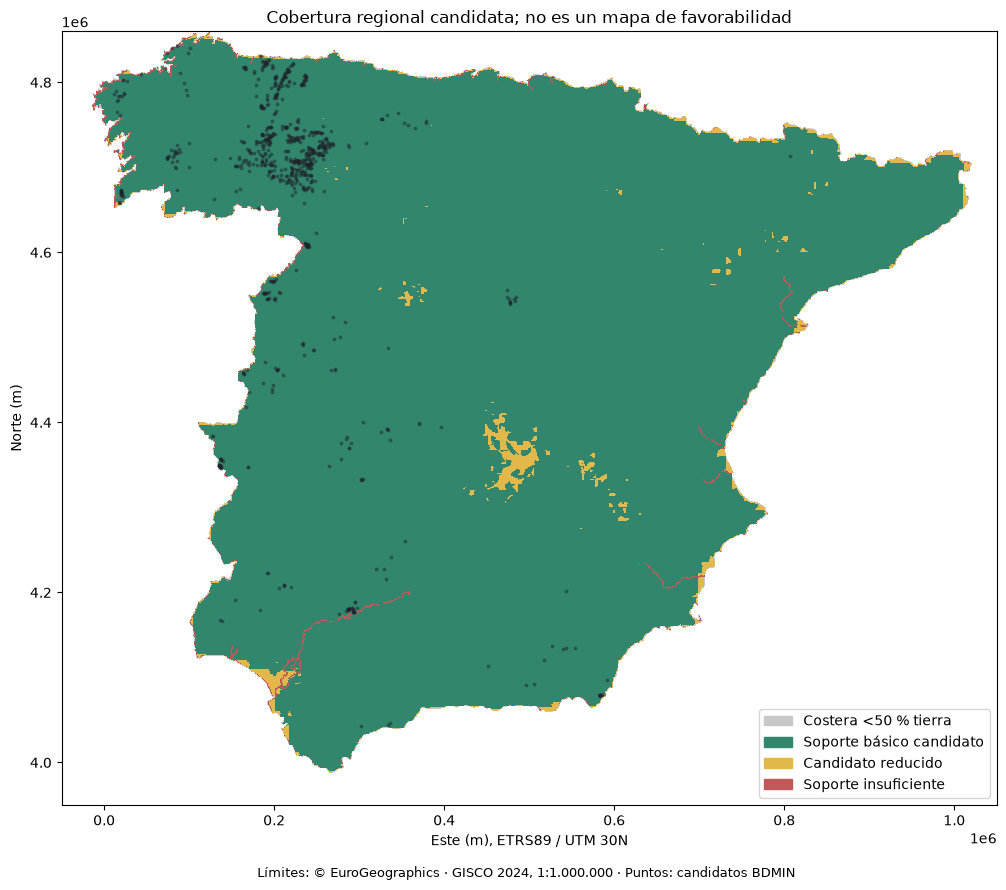

,ambito,familia,area_terrestre_km2,area_valida_km2,area_hueco_km2,candidatos_total,candidatos_celda_cubierta,revisados_celda_cubierta,metodo,porcentaje_area_valida
248,b0_1,geoquimica_au,43.295126,0.000000,43.295126,0,0,0,area_pixeles_validos_intersectada_con_mascara,0.000000
250,b0_11,geoquimica_au,2.499608,0.000000,2.499608,0,0,0,area_pixeles_validos_intersectada_con_mascara,0.000000
257,b0_8,geoquimica_au,5.244942,0.000000,5.244942,0,0,0,area_pixeles_validos_intersectada_con_mascara,0.000000
305,b13_15,geoquimica_au,46.822190,0.000000,46.822190,0,0,0,area_pixeles_validos_intersectada_con_mascara,0.000000
335,b16_11,geoquimica_au,1.911730,0.000000,1.911730,0,0,0,area_pixeles_validos_intersectada_con_mascara,0.000000
369,b2_19,geoquimica_au,18.094861,0.000000,18.094861,0,0,0,area_pixeles_validos_intersectada_con_mascara,0.000000
336,b16_4,geoquimica_au,5.596724,0.000000,5.596724,0,0,0,area_pixeles_validos_intersectada_con_mascara,0.000000
329,b15_4,geoquimica_au,473.339459,100.049232,373.290227,0,0,0,area_pixeles_validos_intersectada_con_mascara,21.136888
372,b2_21,geoquimica_au,43.313636,15.054380,28.259256,0,0,0,area_pixeles_validos_intersectada_con_mascara,34.756676
401,b4_1,geoquimica_au,50.234561,20.736131,29.498430,3,3,0,area_pixeles_validos_intersectada_con_mascara,41.278615


In [14]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
colores = ["#c8c8c8", "#31866d", "#e3b84b", "#bf5856"]
fig, ax = plt.subplots(figsize=(12, 9))
extent = (SPEC["origin_x"], SPEC["origin_x"] + SPEC["width"] * 1000,
          SPEC["origin_y"] - SPEC["height"] * 1000, SPEC["origin_y"])
ax.imshow(np.ma.masked_equal(estados, 0), extent=extent, origin="upper",
          cmap=ListedColormap(colores), norm=BoundaryNorm([.5,1.5,2.5,3.5,4.5], 4), interpolation="nearest")
pts = indicios.to_crs(SPEC["crs"])
pts = pts[~pts.geo_cuarentena]
ax.scatter(pts.geometry.x, pts.geometry.y, s=3, c="#20242a", alpha=.4)
ax.legend(handles=[Patch(color=c, label=l) for c,l in zip(colores,
    ["Costera <50 % tierra", "Soporte básico candidato", "Candidato reducido", "Soporte insuficiente"])], loc="lower right")
ax.set(xlabel="Este (m), ETRS89 / UTM 30N", ylabel="Norte (m)",
       title="Cobertura regional candidata; no es un mapa de favorabilidad", xlim=extent[:2], ylim=extent[2:])
ax.set_aspect("equal")
fig.text(.5, .02, "Límites: © EuroGeographics · GISCO 2024, 1:1.000.000 · Puntos: candidatos BDMIN", ha="center", fontsize=9)
fig.tight_layout(rect=[0,.035,1,1])
fig.savefig(RUN_DIR / "mapa_cobertura.png", dpi=150)
plt.show()
display(cobertura_ambitos[cobertura_ambitos.familia.eq("geoquimica_au") &
                         cobertura_ambitos.ambito.ne("peninsula")].sort_values("porcentaje_area_valida").head(15))

## 11. Controles de cierre y trazabilidad

Los controles ejecutados verifican conservación de área, IDs únicos, relación muchos
a uno sin duplicación, paginación íntegra, categorías válidas, proporciones que suman
uno y coincidencia de píxel en todos los TIFF escritos. Los hashes se vuelven a
comprobar al finalizar; se sella también cada producto para las fases siguientes.

Las pruebas sintéticas adicionales están en `tests/test_territory.py`: clase cero,
NoData, empate, ponderación terrestre, huecos/islas pequeñas, límite de extensión,
bordes de celda y reparación de geometrías. Se ejecutan junto con las pruebas de A/B.

In [15]:
assert control_adicionales.pagination_complete.all()
assert grid_cobertura.cell_id.is_unique
assert len(indicios_celda) == len(indicios)
assert grid_cobertura.n_candidatos.sum() == indicios_celda.cell_id.notna().sum()
assert not grid_cobertura.prediction_allowed.any()
assert control_vectores.pagination_complete.all()
control = finish_run(ROOT, RUN_DIR, MANIFEST_A, ENTRADAS_C, grid_cobertura, indicios_celda, control_vectores)
display(pd.Series(control, dtype=object).to_frame("resultado"))
print("Resultados conservados en:", RUN_DIR)

,resultado
estado_ejecucion,completada
fase_c_cientifica_cerrada,False
celdas_terrestres,496855
area_terrestre_km2_epsg25830,493639.611691
candidatos_asignados,789
candidatos_fuera_mascara_o_no_utilizables,1
positivos_revisados_asignados,0
capas_adicionales_procesadas,"[magnetometriaradiometria, magnetotelurico, medidasestructurales, petrofisica, buzamientos,..."
fuentes_modificadas,[]
entradas_adicionales_modificadas,[]


Resultados conservados en: C:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\reports\fase_c\20260908T103618_420135Z


## 12. Qué se entrega a las fases siguientes

- `grid_1km.csv.gz` + `grid_spec.json`: geometría reconstruible, IDs y área terrestre.
- `feature_dictionary.csv`: soporte uniforme de extracción y variables aún pendientes.
- `vectors/*.gpkg`: familias separadas, CRS métrico, geometrías 2D y FID de origen.
- `rasters/*_1km.tif`: clases/proporciones, elevación y máscaras alineadas.
- `coverage.gpkg`: máscara, ámbitos españoles y estados territoriales.
- `coverage_by_cell.csv.gz`, `coverage_by_scope_family.csv`, `coverage_decisions.csv`:
  soporte por celda, familia y bloque, con estados explícitos.
- `indicios_celda_cobertura.csv`: enlace completo con B, sin deducir nuevos positivos.
- Informes geométricos, revisión de Au sin dato, mapa, hashes y control de cierre.

Antes de declarar H2 aceptado: validar la máscara candidata, revisar incidencias
geométricas y cobertura por hoja/dominio, y resolver las huellas de levantamiento.
Antes de modelizar: completar fase D, revisar etiquetas y depósitos, elegir piloto
por evidencia territorial/geológica y fijar particiones. No se elige el piloto por
el porcentaje que resulte más favorable en este cuaderno.

Referencias primarias para las decisiones implementadas:

- [Plan local, fase C](../informes/PLAN_PROSPECTIVIDAD_AURIFERA_ESPANA.md).
- [GISCO Countries 2024: API de unidades y escalas](https://gisco-services.ec.europa.eu/distribution/v2/countries/countries-2024-units.html).
- [GISCO: atribución y condiciones de límites administrativos](https://ec.europa.eu/eurostat/web/gisco/geodata/administrative-units).
- [GDAL: configuración de linealización de arcos](https://gdal.org/en/stable/user/configoptions.html).